# 1 — Convolução: de sinais a imagens

**Objetivo.** Entender a convolução como uma janela que desliza, multiplica e soma; calcular exemplos 1D e 2D; e observar como *padding*, *stride* e o kernel mudam a saída.

Este tutorial adapta a primeira metade de [`10_convolucao_e_cnn.ipynb`](https://github.com/Atzingen/visao-computacional-fisica/blob/d0167834a4a071272845206812b5c7487a43b61d/notebooks/10_convolucao_e_cnn.ipynb), de Gustavo von Atzingen, preservando a procedência. A parte de CNN foi movida para o notebook 2. A discussão e a API também seguem a [documentação de `Conv2D` do Keras](https://keras.io/api/layers/convolution_layers/convolution2d/).

> Os widgets ajudam quando há um kernel ativo. Logo abaixo de cada widget há uma vista estática equivalente, que continua visível no GitHub e no HTML exportado.

## Preparação

Precisamos apenas de NumPy, Matplotlib e ipywidgets. Se o widget não aparecer no seu leitor, use as figuras estáticas já salvas no notebook.

In [1]:
from pathlib import Path
from urllib.request import urlretrieve

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display
import ipywidgets as widgets


plt.rcParams.update({
    "figure.figsize": (9, 4),
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.2,
})

np.random.seed(42)

## 1. Convolução em uma dimensão

Para funções contínuas, a convolução é

$$(f * g)(t)=\int_{-\infty}^{\infty}f(\tau)g(t-\tau)\,d\tau.$$

Imagine uma cópia invertida de $g$ deslizando sobre $f$. Em cada posição, multiplicamos as duas funções e integramos a sobreposição. Em dados amostrados, a integral vira uma soma:

$$y[i]=\sum_{j=0}^{K-1}x[i+j]k[j].$$

A expressão acima, sem inverter `k`, é tecnicamente **correlação cruzada**. Bibliotecas de visão e camadas `Conv2D` usam essa forma, embora mantenham o nome “convolução”. Como os valores do kernel são escolhidos ou aprendidos, essa convenção não atrapalha a CNN — mas vale conhecer a diferença matemática.

In [2]:
sinal = np.array([1, 2, 3, 4, 5], dtype=float)
kernel = np.array([1, 0, -1], dtype=float)

def correlacao_1d(sinal: np.ndarray, kernel: np.ndarray) -> np.ndarray:
    n_saida = len(sinal) - len(kernel) + 1
    saida = np.zeros(n_saida)
    for i in range(n_saida):
        janela = sinal[i : i + len(kernel)]
        saida[i] = np.sum(janela * kernel)
    return saida

resultado = correlacao_1d(sinal, kernel)
print("sinal:       ", sinal)
print("kernel:      ", kernel)
print("correlação:  ", resultado)
print("convolução:  ", np.convolve(sinal, kernel, mode="valid"))

sinal:        [1. 2. 3. 4. 5.]
kernel:       [ 1.  0. -1.]
correlação:   [-2. -2. -2.]
convolução:   [2. 2. 2.]


No primeiro valor, a janela `[1, 2, 3]` produz `1×1 + 2×0 + 3×(-1) = -2`. O kernel `[1, 0, -1]` responde a variações: regiões constantes ficam próximas de zero; transições produzem valores com módulo maior.

### Widget: acompanhe a multiplicação e a soma

In [3]:
sinal_longo = np.array([0, 0, 1, 1, 1, 3, 3, 2, 2, 0, 0], dtype=float)
kernel_media = np.ones(3) / 3

def desenhar_janela_1d(posicao: int = 0) -> None:
    janela = sinal_longo[posicao : posicao + len(kernel_media)]
    produto = janela * kernel_media
    fig, eixos = plt.subplots(1, 2, figsize=(9, 3))
    eixos[0].stem(range(len(sinal_longo)), sinal_longo, basefmt=" ")
    eixos[0].axvspan(posicao - 0.4, posicao + 2.4, color="#E69F00", alpha=0.25)
    eixos[0].set(title=f"Janela na posição {posicao}", xlabel="amostra", ylabel="valor")
    eixos[1].bar(["1º", "2º", "3º"], produto, color="#0072B2")
    eixos[1].axhline(0, color="0.25", linewidth=1)
    eixos[1].set(title=f"Produtos; soma = {produto.sum():.2f}", ylabel="janela × kernel")
    plt.tight_layout()
    plt.show()

controle_1d = widgets.interactive(
    desenhar_janela_1d,
    posicao=widgets.IntSlider(min=0, max=len(sinal_longo) - 3, step=1, value=0),
)
display(controle_1d)

interactive(children=(IntSlider(value=0, description='posicao', max=8), Output()), _dom_classes=('widget-inter…

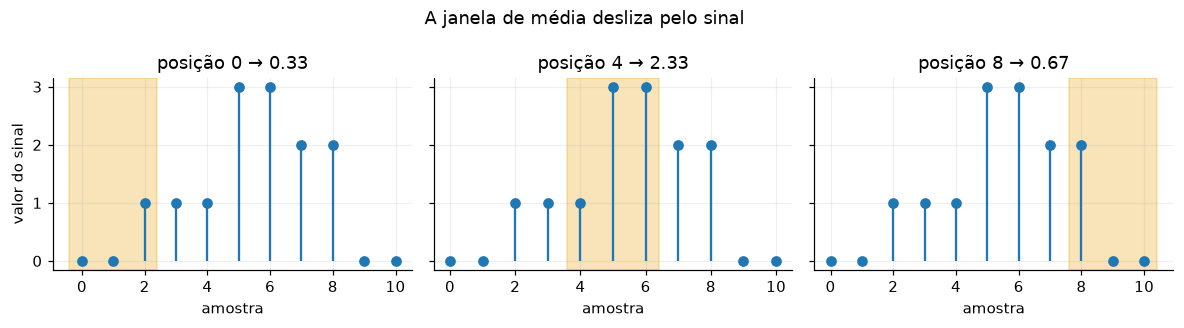

In [4]:
# Vista estática do mesmo processo em três posições.
fig, eixos = plt.subplots(1, 3, figsize=(11, 3), sharey=True)
for eixo, posicao in zip(eixos, [0, 4, 8]):
    eixo.stem(range(len(sinal_longo)), sinal_longo, basefmt=" ")
    eixo.axvspan(posicao - 0.4, posicao + 2.4, color="#E69F00", alpha=0.28)
    valor = np.sum(sinal_longo[posicao : posicao + 3] * kernel_media)
    eixo.set_title(f"posição {posicao} → {valor:.2f}")
    eixo.set_xlabel("amostra")
eixos[0].set_ylabel("valor do sinal")
fig.suptitle("A janela de média desliza pelo sinal")
plt.tight_layout()

## 2. Da linha para a imagem: convolução 2D

Uma imagem em tons de cinza é uma matriz. O kernel agora possui altura e largura:

$$S[i,j]=\sum_m\sum_n I[i+m,j+n]K[m,n].$$

- **Padding** acrescenta uma borda (aqui, de zeros). Com padding 1, um kernel 3×3 pode preservar altura e largura.
- **Stride** é o passo da janela. Stride 2 pula uma posição a cada movimento e reduz a saída.

Para entrada $H\times W$, kernel $K_h\times K_w$, padding $P$ e stride $S$:

$$H_{out}=\left\lfloor\frac{H+2P-K_h}{S}\right\rfloor+1,$$

e a mesma fórmula vale para $W_{out}$. A divisão inteira explica por que algumas posições finais não cabem.

In [5]:
def correlacao_2d(
    imagem: np.ndarray,
    kernel: np.ndarray,
    padding: int = 0,
    stride: int = 1,
) -> np.ndarray:
    imagem_com_borda = np.pad(imagem, padding, mode="constant")
    altura = (imagem_com_borda.shape[0] - kernel.shape[0]) // stride + 1
    largura = (imagem_com_borda.shape[1] - kernel.shape[1]) // stride + 1
    saida = np.zeros((altura, largura))
    for linha in range(altura):
        for coluna in range(largura):
            inicio_linha = linha * stride
            inicio_coluna = coluna * stride
            janela = imagem_com_borda[
                inicio_linha : inicio_linha + kernel.shape[0],
                inicio_coluna : inicio_coluna + kernel.shape[1],
            ]
            saida[linha, coluna] = np.sum(janela * kernel)
    return saida

imagem_pequena = np.array([
    [1, 2, 0, 1],
    [3, 1, 2, 2],
    [0, 1, 3, 1],
    [2, 2, 1, 0],
], dtype=float)
kernel_pequeno = np.array([[1, 0], [0, -1]], dtype=float)

saida_s1 = correlacao_2d(imagem_pequena, kernel_pequeno, stride=1)
saida_s2 = correlacao_2d(imagem_pequena, kernel_pequeno, stride=2)
print("Entrada 4×4:\n", imagem_pequena)
print("\nKernel 2×2:\n", kernel_pequeno)
print("\nSaída, padding 0 e stride 1 (3×3):\n", saida_s1)
print("\nSaída, padding 0 e stride 2 (2×2):\n", saida_s2)

Entrada 4×4:
 [[1. 2. 0. 1.]
 [3. 1. 2. 2.]
 [0. 1. 3. 1.]
 [2. 2. 1. 0.]]

Kernel 2×2:
 [[ 1.  0.]
 [ 0. -1.]]

Saída, padding 0 e stride 1 (3×3):
 [[ 0.  0. -2.]
 [ 2. -2.  1.]
 [-2.  0.  3.]]

Saída, padding 0 e stride 2 (2×2):
 [[ 0. -2.]
 [-2.  3.]]


O primeiro valor é `1×1 + 2×0 + 3×0 + 1×(-1) = 0`. Com stride 2, calculamos menos posições; o kernel não mudou, apenas o caminho da janela.

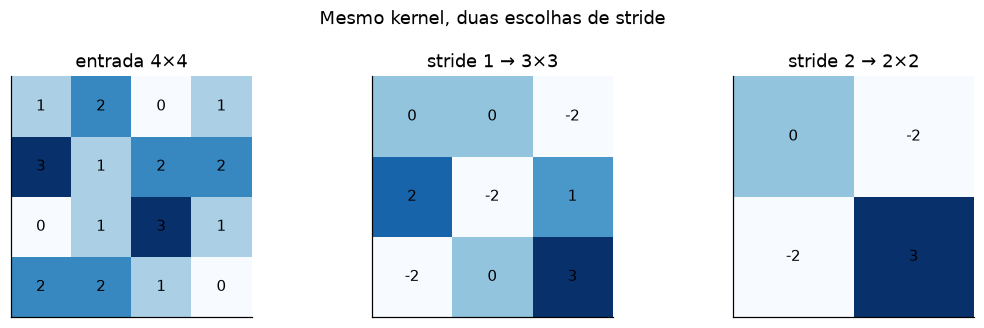

In [6]:
fig, eixos = plt.subplots(1, 3, figsize=(10, 3))
for eixo, dados, titulo in zip(
    eixos,
    [imagem_pequena, saida_s1, saida_s2],
    ["entrada 4×4", "stride 1 → 3×3", "stride 2 → 2×2"],
):
    im = eixo.imshow(dados, cmap="Blues")
    for (linha, coluna), valor in np.ndenumerate(dados):
        eixo.text(coluna, linha, f"{valor:g}", ha="center", va="center", color="black")
    eixo.set_title(titulo)
    eixo.set_xticks([])
    eixo.set_yticks([])
fig.suptitle("Mesmo kernel, duas escolhas de stride")
plt.tight_layout()

## 3. Kernels clássicos em uma imagem real

O frame abaixo vem do experimento da bolinha do repositório de origem. Primeiro procuramos a cópia local em `../imagens/`; se ela não existir (por exemplo, no Colab), baixamos uma cópia para o cache do usuário, fora do repositório.

In [7]:
caminho_local = Path("../imagens/frame_bolinha.png")
if caminho_local.exists():
    caminho_imagem = caminho_local
else:
    caminho_cache = Path.home() / ".cache" / "disciplinas" / "frame_bolinha.png"
    caminho_cache.parent.mkdir(parents=True, exist_ok=True)
    if not caminho_cache.exists():
        url = (
            "https://raw.githubusercontent.com/Atzingen/"
            "visao-computacional-fisica/main/imagens/frame_bolinha.png"
        )
        urlretrieve(url, caminho_cache)
    caminho_imagem = caminho_cache

imagem_rgb = plt.imread(caminho_imagem)[..., :3]
if imagem_rgb.max() > 1:
    imagem_rgb = imagem_rgb / 255.0
imagem_cinza = (
    0.2126 * imagem_rgb[..., 0]
    + 0.7152 * imagem_rgb[..., 1]
    + 0.0722 * imagem_rgb[..., 2]
)
# Redução apenas para a demonstração ficar rápida no navegador.
imagem_cinza = imagem_cinza[::4, ::4]
print("arquivo:", caminho_imagem)
print("forma usada:", imagem_cinza.shape)

arquivo: ../imagens/frame_bolinha.png
forma usada: (104, 160)


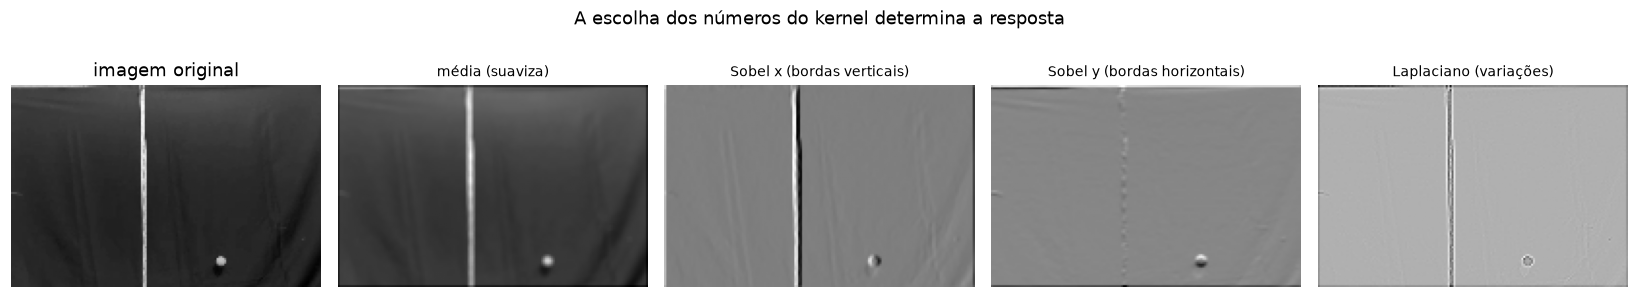

In [8]:
kernels = {
    "média (suaviza)": np.ones((3, 3)) / 9,
    "Sobel x (bordas verticais)": np.array([
        [-1, 0, 1], [-2, 0, 2], [-1, 0, 1]
    ]),
    "Sobel y (bordas horizontais)": np.array([
        [-1, -2, -1], [0, 0, 0], [1, 2, 1]
    ]),
    "Laplaciano (variações)": np.array([
        [0, 1, 0], [1, -4, 1], [0, 1, 0]
    ]),
}

respostas = {
    nome: correlacao_2d(imagem_cinza, kernel, padding=1)
    for nome, kernel in kernels.items()
}

fig, eixos = plt.subplots(1, 5, figsize=(15, 3))
eixos[0].imshow(imagem_cinza, cmap="gray")
eixos[0].set_title("imagem original")
for eixo, (nome, resposta) in zip(eixos[1:], respostas.items()):
    eixo.imshow(resposta, cmap="gray")
    eixo.set_title(nome, fontsize=9)
for eixo in eixos:
    eixo.axis("off")
fig.suptitle("A escolha dos números do kernel determina a resposta")
plt.tight_layout()

### Widget: troque o kernel e compare a matriz com a resposta

In [9]:
def mostrar_kernel(nome: str = "média (suaviza)") -> None:
    kernel = kernels[nome]
    fig, eixos = plt.subplots(1, 3, figsize=(10, 3))
    eixos[0].imshow(imagem_cinza, cmap="gray")
    eixos[0].set_title("entrada")
    eixos[1].imshow(kernel, cmap="coolwarm")
    for (linha, coluna), valor in np.ndenumerate(kernel):
        eixos[1].text(coluna, linha, f"{valor:g}", ha="center", va="center")
    eixos[1].set_title("kernel")
    eixos[2].imshow(respostas[nome], cmap="gray")
    eixos[2].set_title("resposta")
    for eixo in eixos:
        eixo.axis("off")
    fig.suptitle(nome)
    plt.tight_layout()
    plt.show()

controle_kernel = widgets.interactive(
    mostrar_kernel,
    nome=widgets.Dropdown(options=list(kernels), value="média (suaviza)"),
)
display(controle_kernel)

interactive(children=(Dropdown(description='nome', options=('média (suaviza)', 'Sobel x (bordas verticais)', '…

## Checagem e próximos passos

- A saída 2D calculada à mão concorda com a fórmula de tamanho.
- Padding controla a borda; stride controla quantas posições avaliamos.
- Média, Sobel e Laplaciano fazem operações diferentes porque seus números são diferentes.
- Em uma CNN, a operação é a mesma, mas os valores dos kernels são aprendidos a partir dos exemplos.

No próximo notebook, uma rede densa e uma CNN receberão exatamente as mesmas partições do MNIST. Isso permite comparar os modelos sem misturar a diferença de arquitetura com uma diferença nos dados.